In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import fashion_mnist
import cv2

tf.keras.utils.set_random_seed(42)

from IPython.display import display

In [3]:
# Ladda in Fashion MNIST dataset
# https://keras.io/api/datasets/fashion_mnist/
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [4]:
# Storlek och struktur på träningsdata och testdata

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [5]:
print("Unika klasser:", np.unique(y_train))

print("Minsta pixelvärde:", X_train.min())
print("Största pixelvärde:", X_train.max())

Unika klasser: [0 1 2 3 4 5 6 7 8 9]
Minsta pixelvärde: 0
Största pixelvärde: 255


Vi vill dela upp träningsdatan i träning och validation. Vi använder en test storlek på 10% och vi använder stratify så klassfördelningen blir ungefär lika i träning och validation.

In [6]:
X_train_base, X_val_base, y_train_base, y_val_base = train_test_split(
    X_train,
    y_train,
    test_size=0.10,
    random_state=42,
    stratify=y_train
)

print("X_train", X_train_base.shape)
print("X_val", X_val_base.shape)
print("X_test", X_test.shape)

X_train (54000, 28, 28)
X_val (6000, 28, 28)
X_test (10000, 28, 28)


In [7]:
# Lägga till en kanaldimension

X_train_base = X_train_base[..., np.newaxis]
X_val_base = X_val_base[..., np.newaxis]
X_test_base = X_test[..., np.newaxis]

print("X_train shape efter kanal dimension", X_train_base.shape)
print("X_val shape efter kanal dimension", X_val_base.shape)
print("X_test shape efter kanal dimension", X_test_base.shape)

X_train shape efter kanal dimension (54000, 28, 28, 1)
X_val shape efter kanal dimension (6000, 28, 28, 1)
X_test shape efter kanal dimension (10000, 28, 28, 1)


Varje bild i datasetet har storleken 28 × 28 pixlar. En Convolutional Neural Network (CNN) förväntar sig vanligtvis att inputdata har formen (höjd, bredd, kanaler).

För färgbilder används oftast tre kanaler (röd, grön och blå). Eftersom Fashion MNIST består av gråskalebilder har varje bild endast en kanal.

Därför lägger vi till en extra dimension i datan så att varje bild får formen 28 × 28 × 1. Detta gör att datan får rätt format för CNN-modellen. 

3. Bygg en modell (CNN)

- skapa en första fungerande modell
- använda neurala nätverk (t.ex. CNN)
- säkerställa att modellen kan tränas

In [8]:
# Grundmodell med CNN

def create_model():

    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(32, (3,3),
                      activation='relu',
                      padding='same'),

        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3),
                      activation='relu',
                      padding='same'),

        layers.MaxPooling2D((2,2)),

        layers.Flatten(),

        layers.Dense(64, activation='relu'),

        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

4) Träna modellen

- träna modellen på träningsdata
- använda validation
- observera hur modellen utvecklas över tid

In [9]:
model_base = create_model()

history_base = model_base.fit(
    X_train_base,
    y_train_base,
    validation_data=(X_val_base, y_val_base),
    epochs=5,
    batch_size=64
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - accuracy: 0.8358 - loss: 0.6277 - val_accuracy: 0.8565 - val_loss: 0.3762
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - accuracy: 0.8919 - loss: 0.2987 - val_accuracy: 0.8830 - val_loss: 0.3205
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 51s 40ms/step - accuracy: 0.9079 - loss: 0.2528 - val_accuracy: 0.8883 - val_loss: 0.2999
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 46ms/step - accuracy: 0.9192 - loss: 0.2222 - val_accuracy: 0.8942 - val_loss: 0.2963
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - accuracy: 0.9269 - loss: 0.1985 - val_accuracy: 0.8908 - val_loss: 0.3159


In [10]:
model_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 660,704 (2.52 MB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 440,470 (1.68 MB)

Vi kompilerar vår baseline-modell med optimeraren Adam och en learning rate på 0.001. Adam används eftersom den är effektiv för de flesta neurala nätverk och anpassar inlärningshastigheten under träning.

Vi använder Sparse Categorical Crossentropy som loss-funktion eftersom det är ett multiklassklassificeringsproblem där labels är heltal mellan 0 och 9.

Som utvärderingsmetrik använder vi accuracy, eftersom detta är ett relativt balanserat dataset med jämnt fördelade klasser, vilket gör accuracy till ett lämpligt mått för att bedöma modellens prestanda.

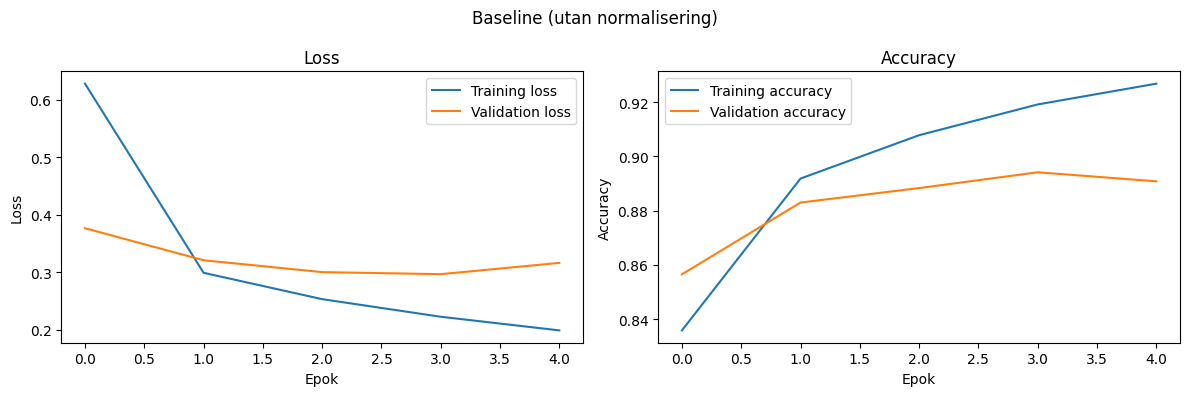

In [11]:
# Träningskurvor

def plot_history(history, title="Träningskurvor"):
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(12,4))

    #Loss
    plt.subplot(1,2,1)
    plt.plot(history_df["loss"], label="Training loss")
    plt.plot(history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    #Accuracy
    plt.subplot(1,2,2)
    plt.plot(history_df["accuracy"], label="Training accuracy")
    plt.plot(history_df["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epok")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_history(history_base, title="Baseline (utan normalisering)")


Modellen lär sig snabbt under de första epokerna. Training loss minskar samtidigt som training accuracy ökar, vilket visar att modellen anpassar sig till träningsdatan.

Även validation loss minskar, vilket tyder på att modellen förbättrar sin generaliseringsförmåga och presterar bättre på ny data.

In [12]:
# Utvärdera på testdata

test_loss_base, test_accuracy_base = model_base.evaluate(X_test_base, y_test, verbose=0)

print(f"Test loss: {test_loss_base:.4f}")
print(f"Test accuracy: {test_accuracy_base:.4f}")

Test loss: 0.3472
Test accuracy: 0.8836


Testresultatet är något sämre än validation-resultatet. Detta är inte ovanligt och kan bero på att validation-setet kommer från samma ursprungliga träningsdata, medan test-setet består av helt osedda bilder.

Validation-resultatet kan därför vara något mer optimistiskt, eftersom modellen indirekt har använts för att övervaka och justera träningen utifrån denna data.

Skillnaden kan även bero på naturlig variation i datan, där testsetet kan innehålla exempel som är svårare att klassificera än validation-setet. Trots detta tyder resultaten på att modellen generaliserar relativt bra.

- Modell 2 (med normalisering)

Vi normaliserar våra pixelvärden. Vi delar alla pixelvärden med 255 så att dem hamnar mellan 0 och 1 istället.

In [13]:
# Normalisering
X_train_norm = X_train_base.astype("float32") / 255.0
X_val_norm = X_val_base.astype("float32") / 255.0
X_test_norm = X_test_base.astype("float32") / 255.0

# Kontrollera minsta och största värden efter normalisering
print("Minsta värde efter normalisering:", X_train_norm.min())
print("Största värde efter normalisering:", X_train_norm.max())

Minsta värde efter normalisering: 0.0
Största värde efter normalisering: 1.0


In [14]:
model_norm = create_model()

history_norm = model_norm.fit(
    X_train_norm,
    y_train_base,
    validation_data=(X_val_norm, y_val_base),
    epochs=5,
    batch_size=64
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 35s 34ms/step - accuracy: 0.8282 - loss: 0.4757 - val_accuracy: 0.8648 - val_loss: 0.3700
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.8880 - loss: 0.3161 - val_accuracy: 0.8972 - val_loss: 0.2938
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.9023 - loss: 0.2681 - val_accuracy: 0.9042 - val_loss: 0.2658
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.9144 - loss: 0.2355 - val_accuracy: 0.9092 - val_loss: 0.2479
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9244 - loss: 0.2090 - val_accuracy: 0.9117 - val_loss: 0.2380


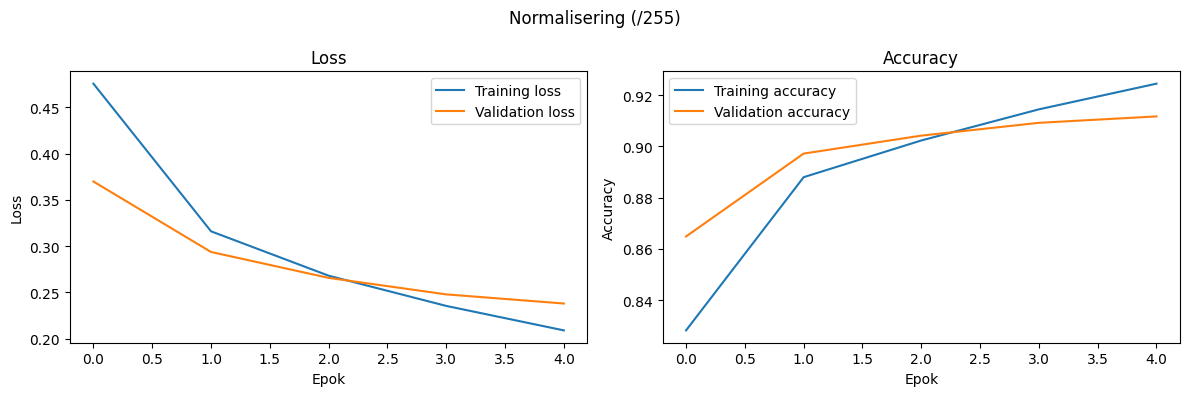

In [15]:
plot_history(history_norm, title="Normalisering (/255)")

Skillnaden mellan training accuracy och validation accuracy är relativt liten, vilket tyder på att modellen generaliserar ganska bra.

In [16]:
# Utvärdera på testdata

test_loss_norm, test_accuracy_norm = model_norm.evaluate(
    X_test_norm,
    y_test,
    verbose=0
)

print(f"Test loss (norm): {test_loss_norm:.4f}")
print(f"Test accuracy (norm): {test_accuracy_norm:.4f}")

Test loss (norm): 0.2738
Test accuracy (norm): 0.9008


- Modell 3 (med standardisering)

In [17]:
# Modell med standardisering
mean = X_train_base.mean()
std = X_train_base.std()

X_train_std = (X_train_base - mean) / std
X_val_std = (X_val_base - mean) / std
X_test_std = (X_test_base - mean) / std

In [18]:
model_std = create_model()

history_std = model_std.fit(
    X_train_std,
    y_train_base,
    validation_data=(X_val_std, y_val_base),
    epochs=5,
    batch_size=64
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 41ms/step - accuracy: 0.8463 - loss: 0.4232 - val_accuracy: 0.8908 - val_loss: 0.2972
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.8996 - loss: 0.2751 - val_accuracy: 0.9035 - val_loss: 0.2640
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 41ms/step - accuracy: 0.9159 - loss: 0.2296 - val_accuracy: 0.9075 - val_loss: 0.2586
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.9279 - loss: 0.1974 - val_accuracy: 0.9138 - val_loss: 0.2418
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9386 - loss: 0.1700 - val_accuracy: 0.9145 - val_loss: 0.2527


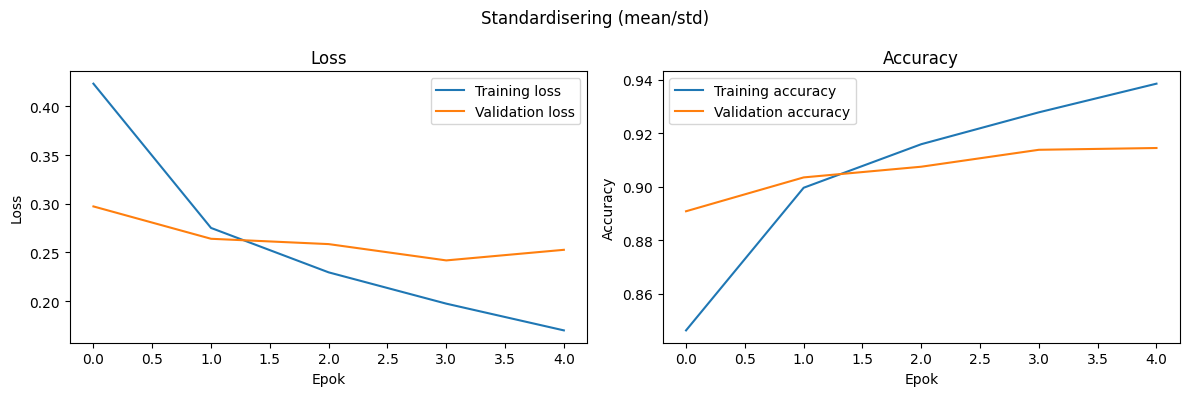

In [19]:
plot_history(history_std, title="Standardisering (mean/std)")

Modellen lär sig snabbt under de första epokerna. Training loss minskar samtidigt som training accuracy ökar, vilket visar att modellen anpassar sig till träningsdatan.

Även validation loss minskar i början, vilket tyder på att modellen förbättrar sin generaliseringsförmåga och presterar bättre på ny data.

Efter några epoker börjar dock validation loss plana ut, medan training loss fortsätter att minska. Detta kan vara ett tidigt tecken på överanpassning (overfitting), där modellen lär sig träningsdatan för väl.

Skillnaden mellan training accuracy och validation accuracy är dock relativt liten, vilket tyder på att modellen fortfarande generaliserar ganska bra.

In [20]:
# Utvärdera på testdata

test_loss_std, test_accuracy_std = model_std.evaluate(
    X_test_std,
    y_test,
    verbose=0
)

print(f"Test loss (std): {test_loss_std:.4f}")
print(f"Test accuracy (std): {test_accuracy_std:.4f}")

Test loss (std): 0.2942
Test accuracy (std): 0.8994


Jämförelse

In [21]:
results = pd.DataFrame({
    "Experiment": ["Baseline", "Normalisering", "Standardisering"],
    "Test Accuracy": [test_accuracy_base, test_accuracy_norm, test_accuracy_std],
    "Test Loss": [test_loss_base, test_loss_norm, test_loss_std]
})

results

,Experiment,Test Accuracy,Test Loss
0,Baseline,0.8836,0.347241
1,Normalisering,0.9008,0.273843
2,Standardisering,0.8994,0.294210


Resolution


In [25]:
resolution = 16

X_train_low = np.array([cv2.resize(img.squeeze(), (resolution, resolution), interpolation=cv2.INTER_LINEAR) for img in X_train_base])
X_val_low = np.array([cv2.resize(img.squeeze(), (resolution, resolution), interpolation=cv2.INTER_LINEAR) for img in X_val_base])
X_test_low = np.array([cv2.resize(img.squeeze(), (resolution, resolution), interpolation=cv2.INTER_LINEAR) for img in X_test_base])

# Add channel dimension
X_train_low = X_train_low[..., np.newaxis]
X_val_low = X_val_low[..., np.newaxis]
X_test_low = X_test_low[..., np.newaxis]

print(f"Resized to {resolution}x{resolution}")
print(f"X_train shape: {X_train_low.shape}")
print(f"X_val shape: {X_val_low.shape}")
print(f"X_test shape: {X_test_low.shape}")

Resized to 16x16
X_train shape: (54000, 16, 16, 1)
X_val shape: (6000, 16, 16, 1)
X_test shape: (10000, 16, 16, 1)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.8125 - loss: 0.6446 - val_accuracy: 0.8428 - val_loss: 0.4267
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8704 - loss: 0.3531 - val_accuracy: 0.8400 - val_loss: 0.4150
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8861 - loss: 0.3108 - val_accuracy: 0.8463 - val_loss: 0.3810
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8960 - loss: 0.2838 - val_accuracy: 0.8643 - val_loss: 0.3484
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9006 - loss: 0.2648 - val_accuracy: 0.8797 - val_loss: 0.3197


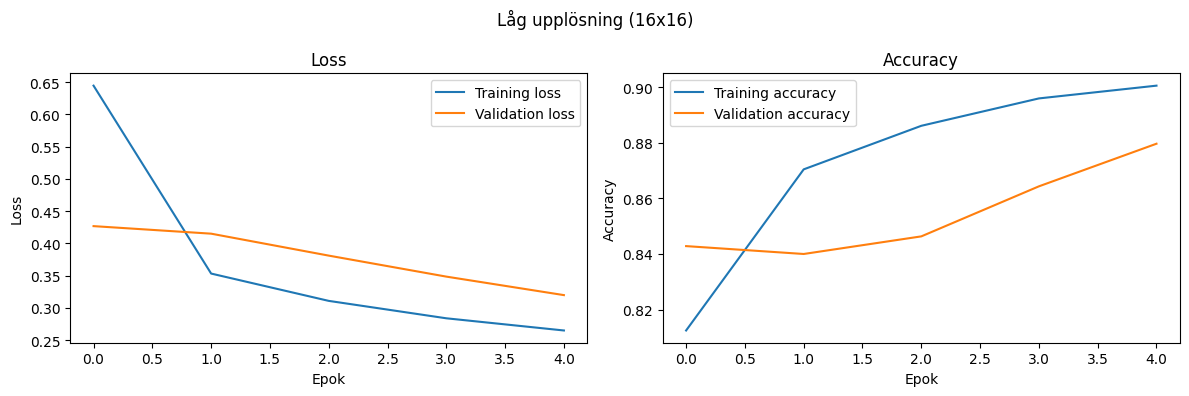

In [26]:
model_low = keras.Sequential([
    layers.Input(shape=(16, 16, 1)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_low.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_low = model_low.fit(
    X_train_low,
    y_train_base,
    validation_data=(X_val_low, y_val_base),
    epochs=5,
    batch_size=64
)

plot_history(history_low, title="Låg upplösning (16x16)")

In [27]:
test_loss_low, test_accuracy_low = model_low.evaluate(
    X_test_low,
    y_test,
    verbose=0
)

print(f"Test loss (låg upplösning): {test_loss_low:.4f}")
print(f"Test accuracy (låg upplösning): {test_accuracy_low:.4f}")

Test loss (låg upplösning): 0.3583
Test accuracy (låg upplösning): 0.8649


Compressed image experiment

Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6468 - loss: 1.0067 - val_accuracy: 0.7640 - val_loss: 0.6315
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7904 - loss: 0.5668 - val_accuracy: 0.8170 - val_loss: 0.5107
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8296 - loss: 0.4789 - val_accuracy: 0.8440 - val_loss: 0.4413
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8538 - loss: 0.4263 - val_accuracy: 0.8540 - val_loss: 0.4116
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8674 - loss: 0.3897 - val_accuracy: 0.8650 - val_loss: 0.3977


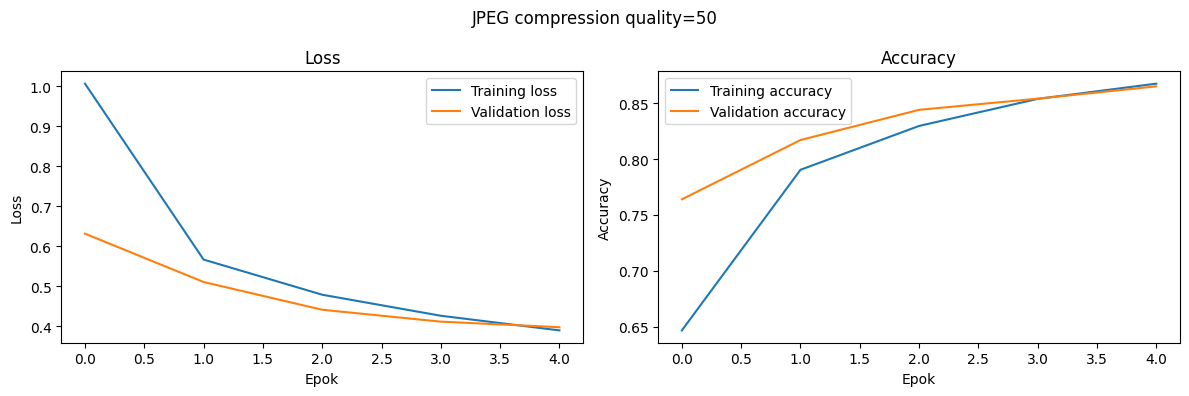

Test loss (compressed): 0.4597
Test accuracy (compressed): 0.8440


In [28]:
# Compress with JPEG quality 50 in-memory and train the same model

def jpeg_compress(images, quality=50):
    compressed = []
    for img in images:
        success, encoded = cv2.imencode('.jpg', img, [cv2.IMWRITE_JPEG_QUALITY, quality])
        compressed_img = cv2.imdecode(encoded, cv2.IMREAD_GRAYSCALE)
        compressed.append(compressed_img)
    return np.array(compressed, dtype='float32')[..., np.newaxis] / 255.0

n_samples = 5000
X_train_comp = jpeg_compress(X_train_base[:n_samples].squeeze())
X_val_comp = jpeg_compress(X_val_base[:1000].squeeze())
X_test_comp = jpeg_compress(X_test_base[:1000].squeeze())

model_comp = create_model()

history_comp = model_comp.fit(
    X_train_comp,
    y_train_base[:n_samples],
    validation_data=(X_val_comp, y_val_base[:1000]),
    epochs=5,
    batch_size=64
)

plot_history(history_comp, title='JPEG compression quality=50')

loss_comp, acc_comp = model_comp.evaluate(X_test_comp, y_test[:1000], verbose=0)
print(f'Test loss (compressed): {loss_comp:.4f}')
print(f'Test accuracy (compressed): {acc_comp:.4f}')

Data augmentation experiment

In [29]:
weak_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08)
])

strong_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.20),
    layers.RandomTranslation(0.15, 0.15),
    layers.RandomZoom(0.20),
    layers.RandomContrast(0.25)
])


def build_dataset(x, y, augmentation=None, batch_size=64):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if augmentation is not None:
        ds = ds.map(lambda x, y: (augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.shuffle(2000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

n_samples = 5000
train_ds_weak = build_dataset(X_train_norm[:n_samples], y_train_base[:n_samples], weak_aug)
train_ds_strong = build_dataset(X_train_norm[:n_samples], y_train_base[:n_samples], strong_aug)
val_ds = build_dataset(X_val_norm[:1000], y_val_base[:1000])
test_ds = build_dataset(X_test_norm[:1000], y_test[:1000])

model_weak = create_model()
history_weak = model_weak.fit(train_ds_weak, validation_data=val_ds, epochs=5)
loss_weak, acc_weak = model_weak.evaluate(test_ds, verbose=0)

model_strong = create_model()
history_strong = model_strong.fit(train_ds_strong, validation_data=val_ds, epochs=5)
loss_strong, acc_strong = model_strong.evaluate(test_ds, verbose=0)

print(f"Weak augmentation test accuracy: {acc_weak:.4f}")
print(f"Strong augmentation test accuracy: {acc_strong:.4f}")

pd.DataFrame({
    "Experiment": ["Weak augmentation", "Strong augmentation"],
    "Test Accuracy": [acc_weak, acc_strong],
    "Test Loss": [loss_weak, loss_strong]
})

Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.5264 - loss: 1.3033 - val_accuracy: 0.7410 - val_loss: 0.7255
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7204 - loss: 0.7881 - val_accuracy: 0.7140 - val_loss: 0.7520
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7420 - loss: 0.7114 - val_accuracy: 0.7590 - val_loss: 0.6668
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7624 - loss: 0.6513 - val_accuracy: 0.7920 - val_loss: 0.5604
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7792 - loss: 0.6099 - val_accuracy: 0.7710 - val_loss: 0.6042
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.2878 - loss: 1.9278 - val_accuracy: 0.5090 - val_loss: 1.3705
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.4194 - loss: 1.5864 - val_accuracy: 0.5950 - val_loss: 1.1496
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.4890 - loss: 1.4535 - val_accuracy: 0.5190 - val_loss:

,Experiment,Test Accuracy,Test Loss
0,Weak augmentation,0.750,0.690595
1,Strong augmentation,0.467,1.457134


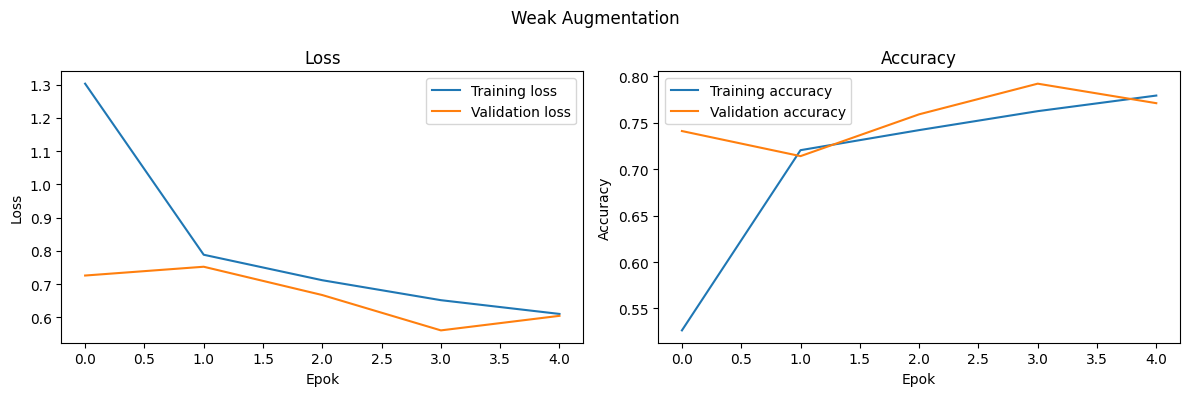

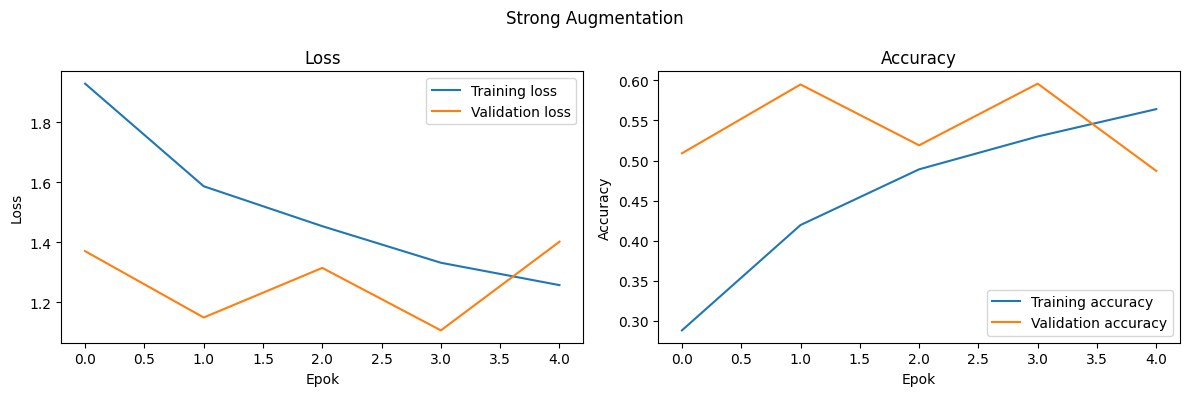

In [32]:
plot_history(history_weak, title="Weak Augmentation")
plot_history(history_strong, title="Strong Augmentation")

In [31]:
plot_history(model_weak, title='Weak augmentation')

ValueError: DataFrame constructor not properly called!

In [ ]:
plot_history(model_strong, title='Strong augmentation')

MixUp experiment

In [30]:
# Simple MixUp: blend pairs of images and labels
n_samples = 5000
x = X_train_norm[:n_samples]
y = y_train_base[:n_samples]

idx = np.random.permutation(n_samples)
lam = np.random.beta(0.2, 0.2, size=n_samples)

x_mix = x * lam[:, None, None, None] + x[idx] * (1 - lam[:, None, None, None])
y_mix = tf.one_hot(y, 10) * lam[:, None] + tf.one_hot(y[idx], 10) * (1 - lam[:, None])

model_mix = create_model()
model_mix.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_mix = model_mix.fit(x_mix, y_mix, validation_data=(X_val_norm[:1000], tf.one_hot(y_val_base[:1000], 10)), epochs=5, batch_size=64)

loss_mix, acc_mix = model_mix.evaluate(X_test_norm[:1000], tf.one_hot(y_test[:1000], 10), verbose=0)
print(f'MixUp test accuracy: {acc_mix:.4f}')

pd.DataFrame({"Experiment": ["MixUp"], "Test Accuracy": [acc_mix], "Test Loss": [loss_mix]})

Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6294 - loss: 1.1909 - val_accuracy: 0.7640 - val_loss: 0.6385
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7832 - loss: 0.8327 - val_accuracy: 0.7990 - val_loss: 0.5330
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8192 - loss: 0.7586 - val_accuracy: 0.8340 - val_loss: 0.4732
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8424 - loss: 0.7052 - val_accuracy: 0.8460 - val_loss: 0.4313
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8596 - loss: 0.6638 - val_accuracy: 0.8550 - val_loss: 0.4148
MixUp test accuracy: 0.8500


,Experiment,Test Accuracy,Test Loss
0,MixUp,0.85,0.461103


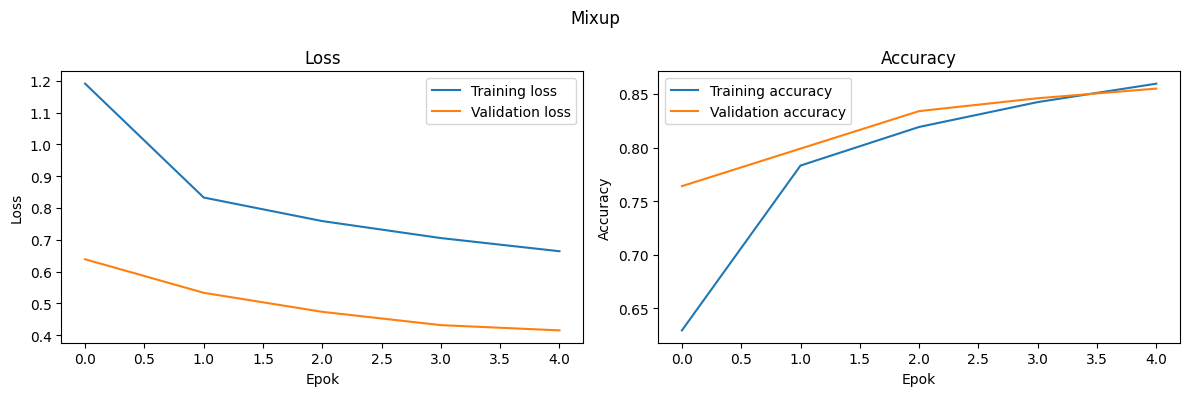

In [33]:
plot_history(history_mix, title='Mixup')

In [39]:

names = ["Baseline","Normalisering (/255)","Standardisering","Låg upplösning (16x16)","Compressed (JPEG q=50)","Weak augmentation","Strong augmentation","MixUp"]
acc_vars = ["test_accuracy_base","test_accuracy_norm","test_accuracy_std","test_accuracy_low","acc_comp","acc_weak","acc_strong","acc_mix"]
loss_vars = ["test_loss_base","test_loss_norm","test_loss_std","test_loss_low","loss_comp","loss_weak","loss_strong","loss_mix"]

df = pd.DataFrame({
    "Experiment": names,
    "Test Accuracy": [globals().get(v, np.nan) for v in acc_vars],
    "Test Loss": [globals().get(v, np.nan) for v in loss_vars],
}).set_index("Experiment")

display(df)


,Test Accuracy,Test Loss
Experiment,,
Baseline,0.8836,0.347241
Normalisering (/255),0.9008,0.273843
Standardisering,0.8994,0.294210
Låg upplösning (16x16),0.8649,0.358299
Compressed (JPEG q=50),0.8440,0.459689
Weak augmentation,0.7500,0.690595
Strong augmentation,0.4670,1.457134
MixUp,0.8500,0.461103


Jämför input-format: Dense (flat) vs CNN

In [41]:


def create_dense(input_dim):
    m = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

# Flat 28x28 (använd normaliserad data)
X_train_flat = X_train_norm.reshape(len(X_train_norm), -1)
X_val_flat = X_val_norm.reshape(len(X_val_norm), -1)
X_test_flat = X_test_norm.reshape(len(X_test_norm), -1)

m_dense28 = create_dense(28*28)
m_dense28.fit(X_train_flat, y_train_base, validation_data=(X_val_flat, y_val_base), epochs=5, batch_size=64, verbose=0)
loss_dense28, acc_dense28 = m_dense28.evaluate(X_test_flat, y_test, verbose=0)

# Flat 16x16 (normalisera lågupplösning och platta)
X_train_low_norm = X_train_low.astype('float32') / 255.0
X_val_low_norm = X_val_low.astype('float32') / 255.0
X_test_low_norm = X_test_low.astype('float32') / 255.0

X_train_low_flat = X_train_low_norm.reshape(len(X_train_low_norm), -1)
X_val_low_flat = X_val_low_norm.reshape(len(X_val_low_norm), -1)
X_test_low_flat = X_test_low_norm.reshape(len(X_test_low_norm), -1)

m_dense16 = create_dense(16*16)
m_dense16.fit(X_train_low_flat, y_train_base, validation_data=(X_val_low_flat, y_val_base), epochs=5, batch_size=64, verbose=0)
loss_dense16, acc_dense16 = m_dense16.evaluate(X_test_low_flat, y_test, verbose=0)

# Sammanställ enkelt (återanvänd CNN-resultat om de finns)
rows = [
    ("CNN 28x28", globals().get('test_accuracy_base', np.nan), globals().get('test_loss_base', np.nan)),
    ("Dense 28x28 (flat)", float(acc_dense28), float(loss_dense28)),
    ("CNN 16x16", globals().get('test_accuracy_low', np.nan), globals().get('test_loss_low', np.nan)),
    ("Dense 16x16 (flat)", float(acc_dense16), float(loss_dense16)),
]

df_comp = pd.DataFrame(rows, columns=["Model", "Test Accuracy", "Test Loss"]).set_index('Model')
display(df_comp)


,Test Accuracy,Test Loss
Model,,
CNN 28x28,0.8836,0.347241
Dense 28x28 (flat),0.8659,0.381637
CNN 16x16,0.8649,0.358299
Dense 16x16 (flat),0.8617,0.377610


**Slutsats — bästa preprocessing**

Enligt testresultaten ger Normalisering (/255) bäst prestanda: **Test accuracy = 0.9008**.

Rekommendation: använd Normalisering (/255) som standardpreprocessing och verifiera med fler seeds eller CV-folds för stabilitet.
